# Laboratorio #3

* Josue Say - 228801
* Flavio Galán - 22386

## Repositorio

- [Enlace](https://github.com/JosueSay/labs-ds/tree/main/lab3)
- [Data](https://drive.google.com/drive/folders/1DZaL352Xo1kNSpZjXH-HmXbgpbyhrx6E?usp=drive_link)

## Análisis exploratorio

In [125]:
from matplotlib.image import imread
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os
import random
from collections import Counter
from PIL import Image

### Constantes

In [126]:
BASE_DIR = "./data_original/train"
IMAGE_DIR = "./images"
REPORT_DIR = "./reports"
MODALITIES = ['m0', 'm1', 'm2', 'm3', 'm4']
DO_EA = False

os.makedirs(IMAGE_DIR, exist_ok=True)
os.makedirs(REPORT_DIR, exist_ok=True)

reportPath = os.path.join(REPORT_DIR, "analisis_exploratorio.txt")

### Generación de reportes

In [127]:
def writeToReport(text, printAlso=True):
    with open(reportPath, "a", encoding="utf-8") as f:
        f.write(text + "\n")
    if printAlso:
        print(text)

In [128]:
def resetReport():
    with open(reportPath, "w", encoding="utf-8") as f:
        f.write("ANÁLISIS EXPLORATORIO DATASET IMAGENES\n\n")

In [129]:
def checkImageResolution(modality='m0'):
    path = os.path.join(BASE_DIR, modality)
    imgPath = os.path.join(path, random.choice(os.listdir(path)))
    img = Image.open(imgPath)
    size = img.size
    writeToReport(f"Ejemplo de resolución de imágen de {modality}: {size}")
    return size

In [130]:
def countDigitsPerModality():
    writeToReport("Distribución de imágenes de dígitos por modalidad:\n")
    for modality in MODALITIES:
        path = os.path.join(BASE_DIR, modality)
        files = os.listdir(path)
        digits = [f.split('.')[-2] for f in files]
        count = Counter(digits)
        writeToReport(f"{modality}:")
        for d in sorted(count):
            writeToReport(f"  Dígito {d}: {count[d]} imágenes")
        writeToReport("")

In [131]:
def countImagesPerModality():
    writeToReport("Total de imágenes por modo:\n")
    for modality in MODALITIES:
        path = os.path.join(BASE_DIR, modality)
        total = len(os.listdir(path))
        writeToReport(f"{modality}: {total} imágenes")
    writeToReport("")

In [132]:
def showDigitExamplesPerModality(digit="5", saveImage=False):
    plt.figure(figsize=(15, 6))
    for i, modality in enumerate(MODALITIES):
        modalityPath = os.path.join(BASE_DIR, modality)
        digitImages = [f for f in os.listdir(modalityPath) if f.endswith(f".{digit}.png")]
        if not digitImages:
            continue

        imgFile = random.choice(digitImages)
        imgPath = os.path.join(modalityPath, imgFile)
        img = mpimg.imread(imgPath)

        plt.subplot(1, 5, i + 1)
        plt.imshow(img, cmap="gray")
        plt.title(f"{modality} - {digit}")
        plt.axis("off")

    plt.suptitle(f"Ejemplo del dígito '{digit}' en las modalidades")
    plt.tight_layout()

    if saveImage:
        savePath = os.path.join(IMAGE_DIR, f"digit_{digit}_modalities.png")
        plt.savefig(savePath)
        writeToReport(f"Image saved to: {savePath}")

    plt.show()

In [133]:
if DO_EA:
    resetReport()
    showDigitExamplesPerModality(digit="2", saveImage=True)
    checkImageResolution(modality="m0")
    countImagesPerModality()
    countDigitsPerModality()

In [134]:
numberToName = {
    0: "zero",
    1: "one",
    2: "two",
    3: "three",
    4: "four",
    5: "five",
    6: "six",
    7: "seven",
    8: "eight",
    9: "nine",
}

In [135]:
def showRandomExamples(folder="data/train", samples=9):
    """
    Muestra imágenes aleatorias de distintas clases desde la carpeta dada.
    """
    plt.figure(figsize=(12, 6))
    for i in range(samples):
        number = random.randint(0, 9)
        subfolder = numberToName[number]
        filename = f'{folder}/{subfolder}/m{random.randint(1,4)}-0.{number}.png'
        try:
            image = imread(filename)
            plt.subplot(3, 3, i + 1)
            plt.imshow(image, cmap="gray")
            plt.title(f"{subfolder}")
            plt.axis("off")
        except FileNotFoundError:
            print(f"Imagen no encontrada: {filename}")
    plt.tight_layout()
    plt.show()

In [136]:
# showRandomExamples()

## Explorando los Datos

### Librerías

In [137]:
from tensorflow.keras.layers import Rescaling
from keras.utils import image_dataset_from_directory

### Cargar data

In [138]:
def loadImageDatasetWithSplit(dataDir="data/train", imageSize=(28, 28), batchSize=1024, valSplit=0.2, seed=123):
    train_ds = image_dataset_from_directory(
        dataDir,
        validation_split=valSplit,
        subset="training",
        seed=seed,
        image_size=imageSize,
        batch_size=batchSize
    )
    val_ds = image_dataset_from_directory(
        dataDir,
        validation_split=valSplit,
        subset="validation",
        seed=seed,
        image_size=imageSize,
        batch_size=batchSize
    )
    return train_ds, val_ds

Esta función carga un conjunto de imágenes desde `data/train` y lo divide automáticamente en dos subconjuntos:

- trains_ds
- val_ds


| Parámetro   | Descripción                                                                                        |
| ----------- | -------------------------------------------------------------------------------------------------- |
| `dataDir`   | Ruta a la carpeta raíz donde están las imágenes organizadas por clase. Por defecto: `"data/train"` |
| `imageSize` | Tamaño al que se redimensionan todas las imágenes. Por defecto: `(28, 28)`                         |
| `batchSize` | Cantidad de imágenes que se agrupan en un lote. Por defecto: `32`                                  |
| `valSplit`  | Porcentaje del conjunto que se reservará como validación. Por defecto: `0.2` (20%)                 |
| `seed`      | Semilla aleatoria que asegura que la división sea reproducible.                                    |

In [139]:
def normalizeDataset(dataset):
    normalization_layer = Rescaling(1./255)
    return dataset.map(lambda x, y: (normalization_layer(x), y))

Como se puede ver las imágenes tienen una gran variedad de fondos, pero en tamaño son todas iguales por lo que no hay que aplicarles transformaciones de resolución.

## Entrenamiento

### Librerias

In [140]:
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from keras.optimizers import SGD
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
import numpy as np
import pickle
import os
from tensorflow.keras import layers

### Constantes

In [141]:
train_ds, val_ds = loadImageDatasetWithSplit()
class_names = train_ds.class_names 
train_ds = normalizeDataset(train_ds)
val_ds = normalizeDataset(val_ds)
results = []
modelsDict = {}

Found 300000 files belonging to 10 classes.
Using 240000 files for training.
Found 300000 files belonging to 10 classes.
Using 60000 files for validation.


In [142]:
train_ds = train_ds.cache().shuffle(1000).prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.cache().prefetch(tf.data.AUTOTUNE)

### Módelos

In [143]:
def buildSimpleCNN(inputShape=(28, 28, 3), numClasses=10):
    model = Sequential([
        Conv2D(32, (3,3), activation='relu', padding='same', input_shape=inputShape),
        MaxPooling2D((2,2)),
        Flatten(),
        Dense(128, activation='relu'),
        Dense(numClasses, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

Esto crea un modelo **de red neuronal convolucional (CNN)** simple:

* `Conv2D`: una capa convolucional que extrae características como bordes y formas locales.
* `MaxPooling2D`: reduce la resolución manteniendo la información importante.
* `Flatten`: convierte la matriz en un vector para pasarla a la red densa.
* `Dense`: capas densas (fully connected) que aprenden relaciones entre las características extraídas.
* `softmax`: convierte la salida en probabilidades sobre 10 clases (números del 0 al 9).

In [144]:
def buildVggStyleCNN(inputShape=(28, 28, 3), numClasses=10, dropoutRate=0.25):
    model = Sequential([
        Conv2D(32, (3,3), activation='relu', padding='same', input_shape=inputShape),
        MaxPooling2D((2,2)),
        Dropout(dropoutRate),
        Conv2D(64, (3,3), activation='relu', padding='same'),
        MaxPooling2D((2,2)),
        Dropout(dropoutRate),
        Flatten(),
        Dense(128, activation='relu'),
        Dense(numClasses, activation='softmax')
    ])
    model.compile(optimizer=SGD(learning_rate=0.01, momentum=0.9),
                  loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

In [145]:
def buildSimpleDenseModel(inputShape=(28, 28, 3), numClasses=10):
    model = Sequential([
        Flatten(input_shape=inputShape),
        Dense(256, activation='relu'),
        Dense(128, activation='relu'),
        Dense(numClasses, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

In [146]:
def trainAndEvaluate(model, trainData, valData, epochs=5, modelName="Model"):
    history = model.fit(trainData, validation_data=valData, epochs=epochs, verbose=1)
    loss, acc = model.evaluate(valData, verbose=0)
    print(f"{modelName} Accuracy: {acc*100:.2f}%")

    # Graficar
    plt.figure(figsize=(12, 4))

    # Pérdida
    plt.subplot(1, 2, 1)
    plt.title("Loss")
    plt.plot(history.history['loss'], label="Train")
    plt.plot(history.history['val_loss'], label="Val")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    # Exactitud
    plt.subplot(1, 2, 2)
    plt.title("Accuracy")
    plt.plot(history.history['accuracy'], label="Train")
    plt.plot(history.history['val_accuracy'], label="Val")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    plt.suptitle(modelName)
    plt.tight_layout()
    plt.show()

    return acc

### Modelo SVM

Para utilizar el model SVM primero tenemos que transformar la data a vectores que entienda SVC. Para esto utilizaremos un modelo VGG16, una CNN que nos permite extraer las características principales de una imagen pequeña y luego extraemos todas las características de todo el dataset de pruebas.

Este proceso demora mucho tiempo, por lo tanto guardamos los datos usando pickle para que futuros coldstarts sean más eficientes.

In [147]:
def runSvmModelPipeline(trainDataset, resultsList, epochs=5):
    # 1. Load the Keras Image Dataset
    image_size = (28*3, 28*3)
    batch_size = 1024

    def resize_images(image, label):
        # Resize image from 28x28 to 84x84
        resized_image = tf.image.resize(image, [28*3, 28*3])
        return resized_image, label

    print("Resizing images...")
    scaled_train_ds = trainDataset.map(resize_images)
    print("Done!")

    # 2. Feature Extraction using a pre-trained VGG16
    base_model = VGG16(weights='imagenet', include_top=False, input_shape=(image_size[0], image_size[1], 3))
    base_model.trainable = False  # Freeze the base model layers

    feature_extractor = tf.keras.Sequential([
        base_model,
        tf.keras.layers.GlobalAveragePooling2D()  # Flatten the output features
    ])

    features = []
    labels = []

    if os.path.exists("modelsData/svm_features") and os.path.exists("modelsData/svm_labels"):
        with open("modelsData/svm_features", "rb") as file:
            features = pickle.load(file)
        with open("modelsData/svm_labels", "rb") as file:
            labels = pickle.load(file)
    else:
        print("Extracting features...")
        for i, (images, batch_labels) in enumerate(scaled_train_ds):
            print(f"Doing {i} of {len(scaled_train_ds)}")
            extracted_features = feature_extractor(images)
            features.append(extracted_features.numpy())
            labels.append(batch_labels.numpy())
        print("Done!")

        os.makedirs("modelsData", exist_ok=True)
        with open("modelsData/svm_features", "wb") as file:
            pickle.dump(features, file)
        with open("modelsData/svm_labels", "wb") as file:
            pickle.dump(labels, file)

    # Una vez se tienen las características extraídas por VGG16, podemos proceder a entrenar el modelo objetivo SVM:
    X = np.concatenate(features, axis=0)
    y = np.concatenate(labels, axis=0)

    # 3. Train-Test Split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # 4. Train the SVM Model
    print("Training SVM Model...")
    svm_model = SVC(kernel='rbf', C=1.0, verbose=True, max_iter=epochs * 50)
    svm_model.fit(X_train, y_train)
    print("Done!")

    # 5. Evaluate the SVM Model
    print("Scoring Model...")
    accuracy = svm_model.score(X_test, y_test)
    print(f"SVM Accuracy: {accuracy}")

    resultsList.append(("SVM Model", accuracy))
    return svm_model

### Hiperparámetros

In [148]:
epochs = 5
dropoutOptions = [0.2, 0.3]

### Ejecutando modelos

Epoch 1/5


/mnt/e/Principal/Descargas/josue/venv/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2025-08-03 00:48:54.914354: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:452] ShuffleDatasetV3:164: Filling up shuffle buffer (this may take a while): 43 of 1000
2025-08-03 00:49:05.034973: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:452] ShuffleDatasetV3:164: Filling up shuffle buffer (this may take a while): 98 of 1000
2025-08-03 00:49:24.976000: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:452] ShuffleDatasetV3:164: Filling up shuffle buffer (this may take a while): 186 of 1000
2025-08-03 00:49:34.954174: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:452] ShuffleDatasetV3:164: Filling u

235/235 ━━━━━━━━━━━━━━━━━━━━ 70s 72ms/step - accuracy: 0.7582 - loss: 0.8244 - val_accuracy: 0.8854 - val_loss: 0.3936
Epoch 2/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9066 - loss: 0.3210 - val_accuracy: 0.9139 - val_loss: 0.2915
Epoch 3/5
235/235 ━━━━━━━━━━━━━━━━━━━━ -1s -2461us/step - accuracy: 0.9298 - loss: 0.2419 - val_accuracy: 0.9331 - val_loss: 0.2289
Epoch 4/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9416 - loss: 0.1996 - val_accuracy: 0.9414 - val_loss: 0.1986
Epoch 5/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9484 - loss: 0.1742 - val_accuracy: 0.9460 - val_loss: 0.1785
Simple CNN Accuracy: 94.60%


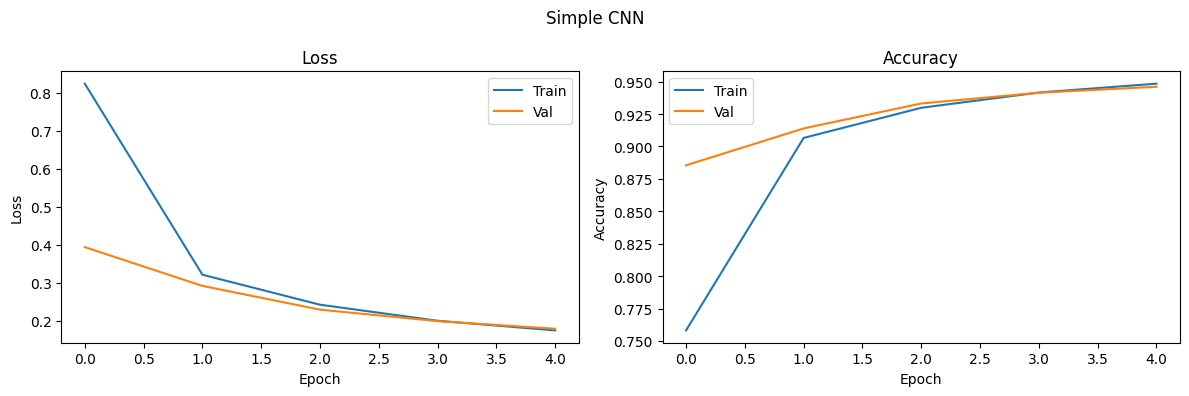

In [149]:
# CNN
modelName = "Simple CNN"
model1 = buildSimpleCNN()
acc1 = trainAndEvaluate(model1, train_ds, val_ds, epochs=epochs, modelName=modelName)
results.append((modelName, acc1))
modelsDict[modelName] = model1

| Aspecto       | Resultado                                                                  |
| ------------- | -------------------------------------------------------------------------- |
| Entrenamiento | Aprende rápidamente y sigue mejorando                                      |
| Validación    | Mejora al inicio, luego se estabiliza                                      |
| Sobreajuste   | Comienza a aparecer levemente después del epoch 3-4                        |

Epoch 1/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 8s 25ms/step - accuracy: 0.5639 - loss: 1.3302 - val_accuracy: 0.8630 - val_loss: 0.4799
Epoch 2/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.8675 - loss: 0.4388 - val_accuracy: 0.9108 - val_loss: 0.3064
Epoch 3/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.9011 - loss: 0.3253 - val_accuracy: 0.9294 - val_loss: 0.2433
Epoch 4/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.9188 - loss: 0.2675 - val_accuracy: 0.9405 - val_loss: 0.2074
Epoch 5/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.9298 - loss: 0.2314 - val_accuracy: 0.9485 - val_loss: 0.1804
VGG Style CNN (Dropout=0.2) Accuracy: 94.85%


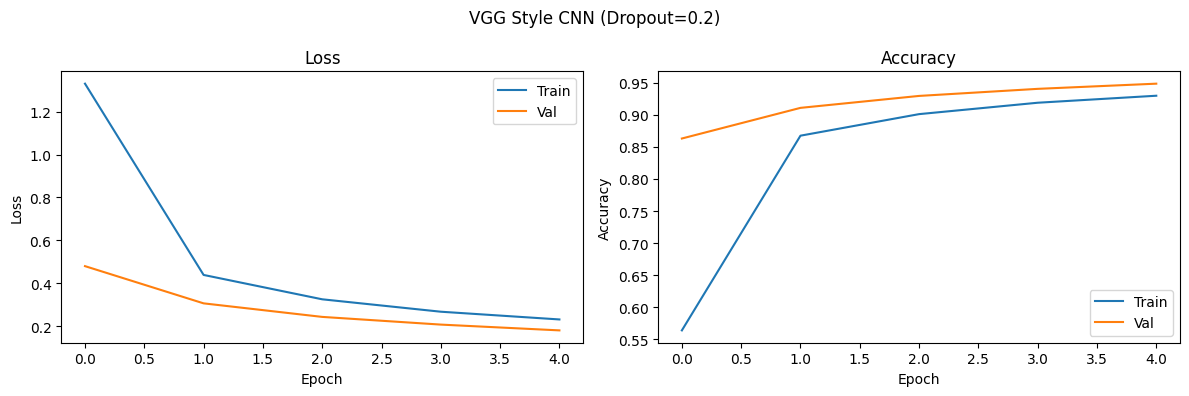

Epoch 1/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.4970 - loss: 1.5035 - val_accuracy: 0.8119 - val_loss: 0.6540
Epoch 2/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.8386 - loss: 0.5288 - val_accuracy: 0.9092 - val_loss: 0.3220
Epoch 3/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.8937 - loss: 0.3509 - val_accuracy: 0.9312 - val_loss: 0.2433
Epoch 4/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.9124 - loss: 0.2875 - val_accuracy: 0.9417 - val_loss: 0.2070
Epoch 5/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.9240 - loss: 0.2515 - val_accuracy: 0.9482 - val_loss: 0.1806
VGG Style CNN (Dropout=0.3) Accuracy: 94.82%


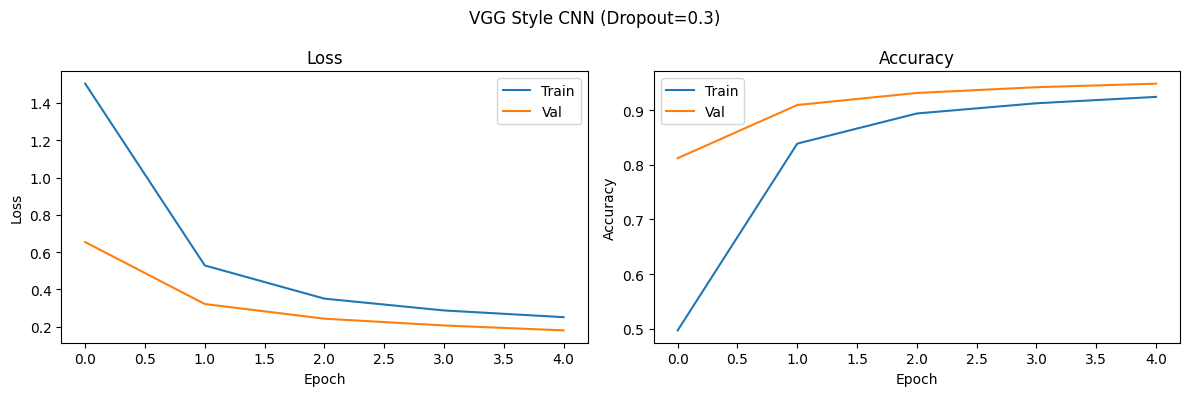

In [150]:
# VGG style con tuning
for dropout in dropoutOptions:
    modelName = f"VGG Style CNN (Dropout={dropout})"
    model = buildVggStyleCNN(dropoutRate=dropout)
    acc = trainAndEvaluate(model, train_ds, val_ds, epochs=epochs, modelName=modelName)
    results.append((modelName, acc))
    modelsDict[modelName] = model

Epoch 1/5


/mnt/e/Principal/Descargas/josue/venv/lib/python3.10/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.5360 - loss: 1.4260 - val_accuracy: 0.6991 - val_loss: 0.9674
Epoch 2/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7303 - loss: 0.8598 - val_accuracy: 0.7558 - val_loss: 0.7712
Epoch 3/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7771 - loss: 0.7092 - val_accuracy: 0.7875 - val_loss: 0.6719
Epoch 4/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7994 - loss: 0.6337 - val_accuracy: 0.8142 - val_loss: 0.5928
Epoch 5/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8155 - loss: 0.5813 - val_accuracy: 0.8194 - val_loss: 0.5749
Simple Dense NN Accuracy: 81.94%


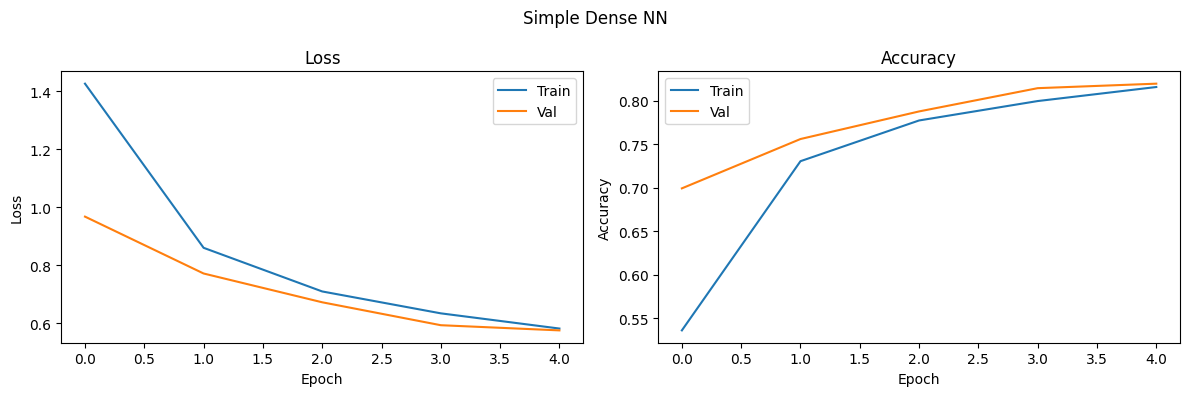

In [151]:
# DL simple
modelName = "Simple Dense NN"
model3 = buildSimpleDenseModel()
acc3 = trainAndEvaluate(model3, train_ds, val_ds, epochs=epochs, modelName=modelName)
results.append((modelName, acc3))
modelsDict[modelName] = model3

In [152]:
svmModel = runSvmModelPipeline(train_ds, results, epochs=epochs)
modelsDict["SVM Model"] = svmModel

Resizing images...
Done!
Training SVM Model...
[LibSVM]WARN: libsvm Solver reached max_iter
optimization finished, #iter = 250
obj = -490.530466, rho = -0.432120
nSV = 500, nBSV = 500
WARN: libsvm Solver reached max_iter
optimization finished, #iter = 250
obj = -487.915004, rho = -0.308763
nSV = 500, nBSV = 500
WARN: libsvm Solver reached max_iter
optimization finished, #iter = 250
obj = -492.792625, rho = -0.514584
nSV = 500, nBSV = 500
WARN: libsvm Solver reached max_iter
optimization finished, #iter = 250
obj = -473.511765, rho = -0.061352
nSV = 500, nBSV = 500
WARN: libsvm Solver reached max_iter
optimization finished, #iter = 250
obj = -485.368610, rho = -0.456146
nSV = 500, nBSV = 500
WARN: libsvm Solver reached max_iter
optimization finished, #iter = 250
obj = -483.117127, rho = -0.424111
nSV = 500, nBSV = 500
WARN: libsvm Solver reached max_iter
optimization finished, #iter = 250
obj = -489.752338, rho = -0.853607
nSV = 500, nBSV = 500
WARN: libsvm Solver reached max_iter
optim

/mnt/e/Principal/Descargas/josue/venv/lib/python3.10/site-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=250).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


SVM Accuracy: 0.396625


In [153]:
print("--- Resumen resultados ---")
for name, acc in results:
    print(f"{name}: {acc*100:.2f}%")

bestModel = max(results, key=lambda x: x[1])
print(f"\nMejor modelo: {bestModel[0]} con precisión {bestModel[1]*100:.2f}%")

--- Resumen resultados ---
Simple CNN: 94.60%
VGG Style CNN (Dropout=0.2): 94.85%
VGG Style CNN (Dropout=0.3): 94.82%
Simple Dense NN: 81.94%
SVM Model: 39.66%

Mejor modelo: VGG Style CNN (Dropout=0.2) con precisión 94.85%


## Predicción

In [154]:
import numpy as np
from PIL import Image
import os
import matplotlib.pyplot as plt
import numpy as np
import pickle
from tensorflow.keras.models import save_model
from tensorflow.keras.models import load_model

### Constantes

In [155]:
SAVE_MODELS = False
LOAD_MODELS = False
USE_LOADED_MODELS = False

In [156]:
def loadAndPrepareImages(folderPath, imageSize=(28, 28), verbose=True):
    """
    Carga imágenes desde una carpeta, las redimensiona, convierte a RGB y normaliza.
    Retorna:
    - numpy array [N, 28, 28, 3]
    - lista con nombres de archivo
    """
    images = []
    filenames = []

    if verbose:
        print(f"\nCargando imágenes desde: {folderPath}\n")

    for idx, file in enumerate(os.listdir(folderPath)):
        if file.endswith(".png"):
            try:
                imgPath = os.path.join(folderPath, file)
                img = Image.open(imgPath).convert("RGB")
                img = img.resize(imageSize)
                imgArray = np.array(img).astype("float32") / 255.0
                images.append(imgArray)
                filenames.append(file)

                if verbose:
                    print(f"[{idx+1}] Cargada: {file}")
            except Exception as e:
                print(f"\tError con {file}: {e}")

    if verbose:
        print(f"\nTotal de imágenes cargadas: {len(images)}")

    return np.array(images), filenames

In [157]:
def showPredictions(images, filenames, preds, confs, samples=5, verbose=True):
    """
    Muestra imágenes con predicción y confianza. Si samples=-1, muestra todas las imágenes.
    """
    if verbose:
        print("\nResultados de predicción:\n")
        for i in range(len(images)):
            print(f"[{i+1}] Imagen: {filenames[i]}")
            print(f"\t - Predicción: {preds[i]}")
            print(f"\t - Confianza: {confs[i]:.4f}\n")

    # Mostrar todas si samples == -1
    total = len(images) if samples == -1 else min(samples, len(images))

    cols = min(5, total)
    rows = (total + cols - 1) // cols

    plt.figure(figsize=(3 * cols, 3 * rows))
    for i in range(total):
        plt.subplot(rows, cols, i + 1)
        plt.imshow(images[i])
        plt.title(f"{filenames[i]}\nPred: {preds[i]} ({confs[i]:.2f})")
        plt.axis("off")
    plt.tight_layout()
    plt.show()

In [158]:
def getIndexToDigitMap(class_names):
    nameToNumber = {
        "zero": 0, "one": 1, "two": 2, "three": 3, "four": 4,
        "five": 5, "six": 6, "seven": 7, "eight": 8, "nine": 9
    }
    return [nameToNumber[name] for name in class_names]

### Cargar modelos

In [159]:
def loadModelsFromDisk(loadDir="./models"):
    """
    Carga todos los modelos guardados en la carpeta indicada.
    Retorna un diccionario con nombre legible → modelo cargado.
    """
    modelsLoaded = {}

    for file in os.listdir(loadDir):
        filepath = os.path.join(loadDir, file)

        # Extraer nombre legible (reverso de cómo lo guardaste)
        modelName = file.replace("_", " ").replace(".keras", "").replace(".pkl", "")
        modelName = modelName.title()

        if file.endswith(".keras"):
            print(f"Cargando modelo Keras desde {filepath}")
            model = load_model(filepath)
        elif file.endswith(".pkl"):
            print(f"Cargando modelo SVM desde {filepath}")
            with open(filepath, "rb") as f:
                model = pickle.load(f)
        else:
            print(f"Archivo no reconocido: {file}")
            continue

        modelsLoaded[modelName] = model

    print(f"\nModelos cargados: {len(modelsLoaded)}")
    return modelsLoaded

In [160]:
if LOAD_MODELS:
    modelsLoaded = loadModelsFromDisk()
    print("Modelos disponibles:")
    for name in modelsLoaded:
        print(f" - {name}")
    USE_LOADED_MODELS = True
else:
    print("Modelos disponibles:")
    for name in modelsDict:
        print(f" - {name}")

Modelos disponibles:
 - Simple CNN
 - VGG Style CNN (Dropout=0.2)
 - VGG Style CNN (Dropout=0.3)
 - Simple Dense NN
 - SVM Model



Cargando imágenes desde: ./test

[1] Cargada: 0.png
[2] Cargada: 0v.png
[3] Cargada: 1.png
[4] Cargada: 2.png
[5] Cargada: 3.png
[6] Cargada: 4.png
[7] Cargada: 4v.png
[8] Cargada: 5.png
[9] Cargada: 6.png
[10] Cargada: 7.png
[11] Cargada: 8.png
[12] Cargada: 9.png

Total de imágenes cargadas: 12
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step

Resultados de predicción:

[1] Imagen: 0.png
	 - Predicción: 0
	 - Confianza: 0.9997

[2] Imagen: 0v.png
	 - Predicción: 0
	 - Confianza: 0.6044

[3] Imagen: 1.png
	 - Predicción: 1
	 - Confianza: 0.9952

[4] Imagen: 2.png
	 - Predicción: 2
	 - Confianza: 0.9998

[5] Imagen: 3.png
	 - Predicción: 3
	 - Confianza: 0.9993

[6] Imagen: 4.png
	 - Predicción: 4
	 - Confianza: 0.9841

[7] Imagen: 4v.png
	 - Predicción: 4
	 - Confianza: 0.9883

[8] Imagen: 5.png
	 - Predicción: 5
	 - Confianza: 0.8998

[9] Imagen: 6.png
	 - Predicción: 5
	 - Confianza: 0.9801

[10] Imagen: 7.png
	 - Predicción: 2
	 - Confianza: 0.7306

[11] Imagen: 8.png
	 - Predicción: 8
	 - C

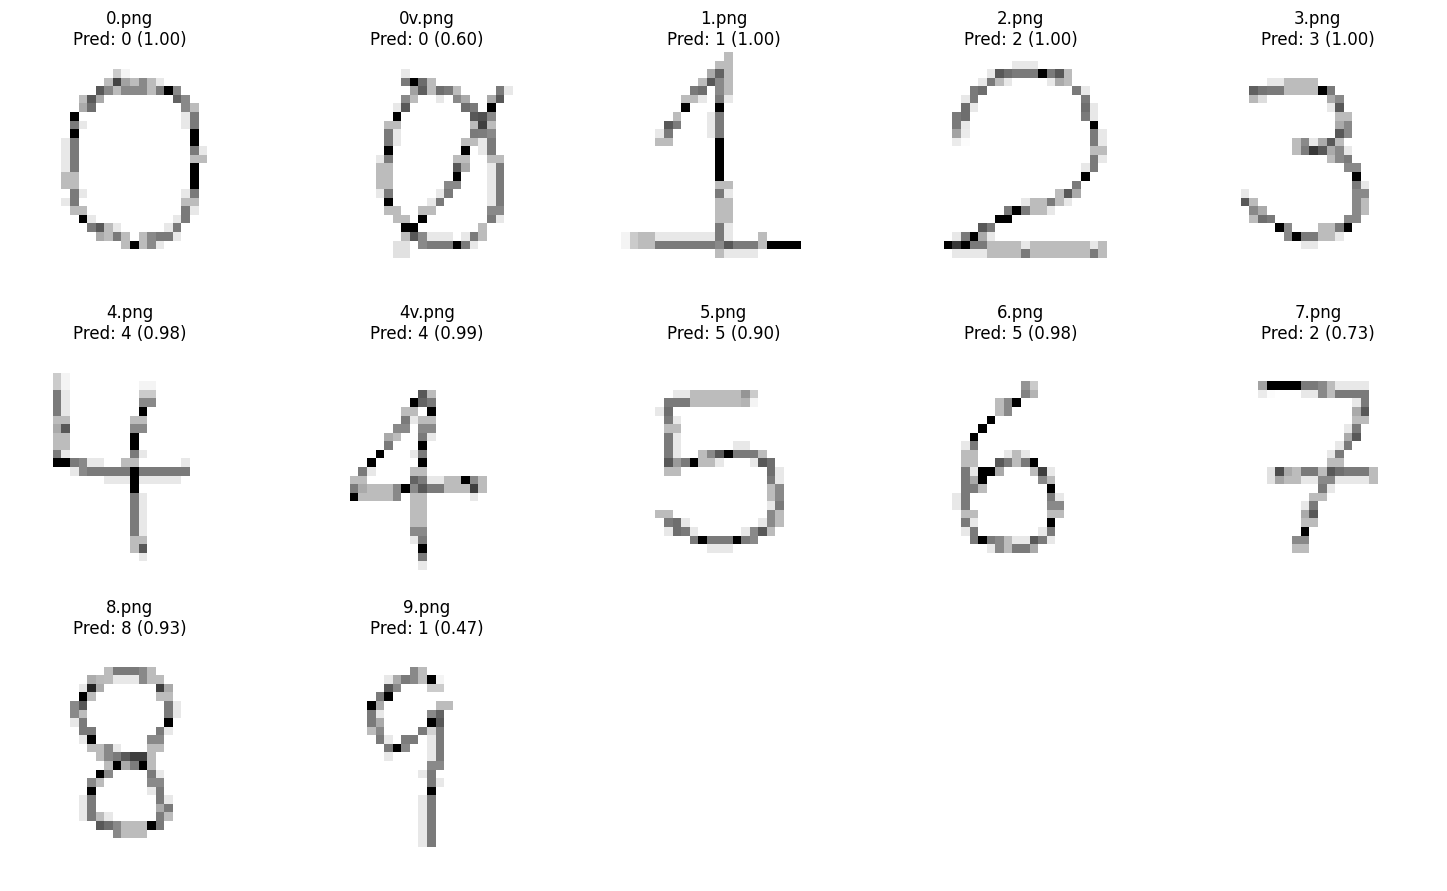

In [168]:
if USE_LOADED_MODELS:
    bestModel = modelsLoaded["Simple Cnn"]
else:
    bestModel = modelsDict["VGG Style CNN (Dropout=0.2)"]

# Cargar imágenes de prueba
images, filenames = loadAndPrepareImages("./test", verbose=True)

# Predecir
preds = bestModel.predict(images)

# Mapear índices a dígitos reales
index_to_digit = getIndexToDigitMap(class_names)
predIndices = np.argmax(preds, axis=1)
predClasses = [index_to_digit[i] for i in predIndices]

# Confianza
confs = np.max(preds, axis=1)

# Mostrar resultados
showPredictions(images, filenames, predClasses, confs, samples=-1, verbose=True)

## Guardando modelos

In [162]:
def saveModelsToDisk(modelsDict, saveDir="./models"):
    os.makedirs(saveDir, exist_ok=True)

    for name, model in modelsDict.items():
        filename = name.lower().replace(" ", "_").replace("(", "").replace(")", "").replace("=", "").replace(".", "")
        filepath = os.path.join(saveDir, f"{filename}")

        if "svm" in filename:
            filepath += ".pkl"
            print(f"Guardando modelo '{name}' como Pickle en {filepath}")
            with open(filepath, "wb") as f:
                pickle.dump(model, f)
        else:
            filepath += ".keras"
            print(f"Guardando modelo '{name}' como Keras en {filepath}")
            model.save(filepath)

    print(f"\nTodos los modelos guardados en: {saveDir}")

In [163]:
if SAVE_MODELS:
    saveModelsToDisk(modelsDict)